In [169]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

In [170]:
#IMPORT LIBRARIES

import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.impute import SimpleImputer

from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.neighbors import KNeighborsClassifier
from sklearn.cluster import DBSCAN
from sklearn.ensemble import RandomForestClassifier

import xgboost as xgb

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix,
    classification_report,
    roc_auc_score
)

from imblearn.over_sampling import SMOTE

In [171]:
#LOAD DATASET

df = pd.read_csv("D:/ML Project/archive/Imperfect_HR_Attrition (1).csv")

print("FIRST 5 ROWS")
pd.set_option('display.max_columns', None)
display(df.head())

# UNDERSTAND DATASET
print("DATASET SHAPE")
print(df.shape)

print("\nDATASET INFO")
print(df.info())

print("\nNULL VALUES")
print(df.isnull().sum())

print("\nSTATISTICAL SUMMARY")
display(df.describe())

FIRST 5 ROWS


,Age,Attrition,BusinessTravel,DailyRate,Department,DistanceFromHome,Education,EducationField,EmployeeCount,EmployeeNumber,EnvironmentSatisfaction,Gender,HourlyRate,JobInvolvement,JobLevel,JobRole,JobSatisfaction,MaritalStatus,MonthlyIncome,MonthlyRate,NumCompaniesWorked,Over18,OverTime,PercentSalaryHike,PerformanceRating,RelationshipSatisfaction,StandardHours,StockOptionLevel,TotalWorkingYears,TrainingTimesLastYear,WorkLifeBalance,YearsAtCompany,YearsInCurrentRole,YearsSinceLastPromotion,YearsWithCurrManager
0,37,No,Travel_Rarely,558,Sales,2.0,3,Marketing,1,656,4.0,Male,75,3,2,Sales Executive,3.0,Married,9602.0,3010,4.0,Y,Yes,11.0,3,3.0,80,1,17.0,3.0,2.0,3,0,1,0.0
1,42,No,Travel_Rarely,265,Sales,5.0,2,Marketing,1,1029,4.0,Male,90,3,5,Manager,3.0,Married,18303.0,7770,6.0,Y,No,13.0,3,2.0,80,0,21.0,3.0,4.0,1,0,0,0.0
2,19,Yes,Travel_Frequently,602,Sales,1.0,1,Technical Degree,1,235,3.0,Female,100,1,1,Sales Representative,1.0,Single,2325.0,20989,0.0,Y,No,21.0,4,1.0,80,0,1.0,5.0,4.0,0,0,0,0.0
3,40,Yes,Travel_Rarely,1329,Research & Development,7.0,3,Life Sciences,1,1649,1.0,Male,73,3,1,Laboratory Technician,1.0,Single,2166.0,3339,3.0,Y,Yes,14.0,3,2.0,80,0,10.0,3.0,1.0,4,2,0,3.0
4,26,No,Travel_Rarely,1167,Sales,5.0,3,Other,1,2060,4.0,Female,30,2,1,Sales Representative,3.0,Single,2966.0,21378,0.0,Y,No,0.0,3,4.0,80,0,5.0,2.0,3.0,4,2,0,0.0


DATASET SHAPE
(1749, 35)

DATASET INFO
<class 'pandas.DataFrame'>
RangeIndex: 1749 entries, 0 to 1748
Data columns (total 35 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   Age                       1749 non-null   int64  
 1   Attrition                 1749 non-null   str    
 2   BusinessTravel            1749 non-null   str    
 3   DailyRate                 1749 non-null   int64  
 4   Department                1749 non-null   str    
 5   DistanceFromHome          1640 non-null   float64
 6   Education                 1749 non-null   int64  
 7   EducationField            1749 non-null   str    
 8   EmployeeCount             1749 non-null   int64  
 9   EmployeeNumber            1749 non-null   int64  
 10  EnvironmentSatisfaction   1614 non-null   float64
 11  Gender                    1680 non-null   str    
 12  HourlyRate                1749 non-null   int64  
 13  JobInvolvement            1749 non-

,Age,DailyRate,DistanceFromHome,Education,EmployeeCount,EmployeeNumber,EnvironmentSatisfaction,HourlyRate,JobInvolvement,JobLevel,JobSatisfaction,MonthlyIncome,MonthlyRate,NumCompaniesWorked,PercentSalaryHike,PerformanceRating,RelationshipSatisfaction,StandardHours,StockOptionLevel,TotalWorkingYears,TrainingTimesLastYear,WorkLifeBalance,YearsAtCompany,YearsInCurrentRole,YearsSinceLastPromotion,YearsWithCurrManager
count,1749.000000,1749.000000,1640.000000,1749.000000,1749.0,1749.000000,1614.000000,1749.000000,1749.000000,1749.000000,1608.000000,1728.000000,1749.000000,1592.000000,1660.000000,1749.000000,1607.000000,1749.0,1749.000000,1748.000000,1622.000000,1619.000000,1749.000000,1749.000000,1749.00000,1666.000000
mean,36.390509,802.419097,9.488415,2.899943,1.0,1035.115495,2.679058,65.792453,2.686678,2.003431,2.695274,6442.207755,14244.236135,2.760050,15.165060,3.159520,2.662103,80.0,0.763293,10.818650,2.771270,2.735639,6.762722,4.029160,2.18582,3.990396
std,9.278006,404.683953,8.233912,1.017999,0.0,598.999189,1.108428,20.368960,0.734995,1.095544,1.113554,5531.862108,7140.406050,2.560683,3.952458,0.366265,1.094968,0.0,0.873590,7.788398,1.268452,0.719177,6.125991,3.589929,3.20831,3.544809
min,18.000000,102.000000,1.000000,1.000000,1.0,1.000000,1.000000,30.000000,1.000000,1.000000,1.000000,1009.000000,2094.000000,0.000000,0.000000,3.000000,1.000000,80.0,0.000000,0.000000,0.000000,1.000000,0.000000,0.000000,0.00000,0.000000
25%,29.000000,459.000000,2.000000,2.000000,1.0,502.000000,2.000000,48.000000,2.000000,1.000000,2.000000,2800.000000,8040.000000,1.000000,12.000000,3.000000,2.000000,80.0,0.000000,6.000000,2.000000,2.000000,2.000000,2.000000,0.00000,2.000000
50%,35.000000,798.000000,7.000000,3.000000,1.0,1043.000000,3.000000,66.000000,3.000000,2.000000,3.000000,4776.000000,14255.000000,2.000000,14.000000,3.000000,3.000000,80.0,1.000000,9.000000,3.000000,3.000000,5.000000,3.000000,1.00000,3.000000
75%,42.000000,1162.000000,15.000000,4.000000,1.0,1554.000000,4.000000,84.000000,3.000000,3.000000,4.000000,7995.250000,20489.000000,4.000000,18.000000,3.000000,4.000000,80.0,1.000000,14.000000,3.000000,3.000000,9.000000,7.000000,3.00000,7.000000
max,60.000000,1499.000000,29.000000,5.000000,1.0,2068.000000,4.000000,100.000000,4.000000,5.000000,4.000000,99800.000000,26999.000000,9.000000,25.000000,4.000000,4.000000,80.0,3.000000,40.000000,6.000000,4.000000,40.000000,18.000000,15.00000,17.000000


In [172]:
#HANDLE NULL VALUES & REMOVE DUPLICATES

# Remove duplicate rows
print("DUPLICATE ROWS BEFORE DROPPING:")
print(df.duplicated().sum())

df.drop_duplicates(inplace=True)

print("\nDUPLICATE ROWS AFTER DROPPING:")
print(df.duplicated().sum())

# Check null values
print("\nNULL VALUES BEFORE IMPUTATION:")
print(df.isnull().sum())

# Apply imputer to handle null values
numeric_cols = df.select_dtypes(include=['number']).columns
categorical_cols = df.select_dtypes(include=['object']).columns

# Impute numeric columns with mean
if len(numeric_cols) > 0:
    numeric_imputer = SimpleImputer(strategy='mean')
    df[numeric_cols] = numeric_imputer.fit_transform(df[numeric_cols])

# Impute categorical columns with most frequent value
if len(categorical_cols) > 0:
    categorical_imputer = SimpleImputer(strategy='most_frequent')
    df[categorical_cols] = categorical_imputer.fit_transform(df[categorical_cols])

print("\nNULL VALUES AFTER IMPUTATION:")
print(df.isnull().sum())

print("\nDATASET SHAPE AFTER CLEANING:", df.shape)

DUPLICATE ROWS BEFORE DROPPING:
97

DUPLICATE ROWS AFTER DROPPING:
0

NULL VALUES BEFORE IMPUTATION:
Age                           0
Attrition                     0
BusinessTravel                0
DailyRate                     0
Department                    0
DistanceFromHome            109
Education                     0
EducationField                0
EmployeeCount                 0
EmployeeNumber                0
EnvironmentSatisfaction     133
Gender                       69
HourlyRate                    0
JobInvolvement                0
JobLevel                      0
JobRole                       0
JobSatisfaction             141
MaritalStatus                 0
MonthlyIncome                20
MonthlyRate                   0
NumCompaniesWorked          157
Over18                        0
OverTime                      0
PercentSalaryHike            88
PerformanceRating             0
RelationshipSatisfaction    141
StandardHours                 0
StockOptionLevel              0
Tot

C:\Users\hp\AppData\Local\Temp\ipykernel_330064\4234094982.py:18: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  categorical_cols = df.select_dtypes(include=['object']).columns


In [173]:
#LABEL ENCODING

label_encoders = {}

for col in df.select_dtypes(include='object').columns:
    
    le = LabelEncoder()
    
    df[col] = le.fit_transform(df[col])
    
    label_encoders[col] = le

print("LABEL ENCODING COMPLETED")

LABEL ENCODING COMPLETED


C:\Users\hp\AppData\Local\Temp\ipykernel_330064\3410119969.py:5: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  for col in df.select_dtypes(include='object').columns:


In [174]:
#FIND CONSTANT & ID COLUMNS
constant_columns = []
id_like_columns = []

for col in df.columns:
    
    unique_values = df[col].nunique()
    
    # Constant columns
    if unique_values == 1:
        constant_columns.append(col)
    
    # Unique ID-like columns
    elif unique_values == len(df):
        id_like_columns.append(col)

print("Constant Columns :")
print(constant_columns)

print("\nUnique ID Columns :")
print(id_like_columns)

Constant Columns :
['EmployeeCount', 'Over18', 'StandardHours']

Unique ID Columns :
[]


In [175]:
#DROP CONSTANT & ID COLUMNS
drop_columns = [
    'EmployeeCount',
    'EmployeeNumber',
    'Over18',
    'StandardHours'
]

df.drop(columns=drop_columns, inplace=True)

print("Columns dropped successfully")

print("\nCurrent Shape :", df.shape)

Columns dropped successfully

Current Shape : (1652, 31)


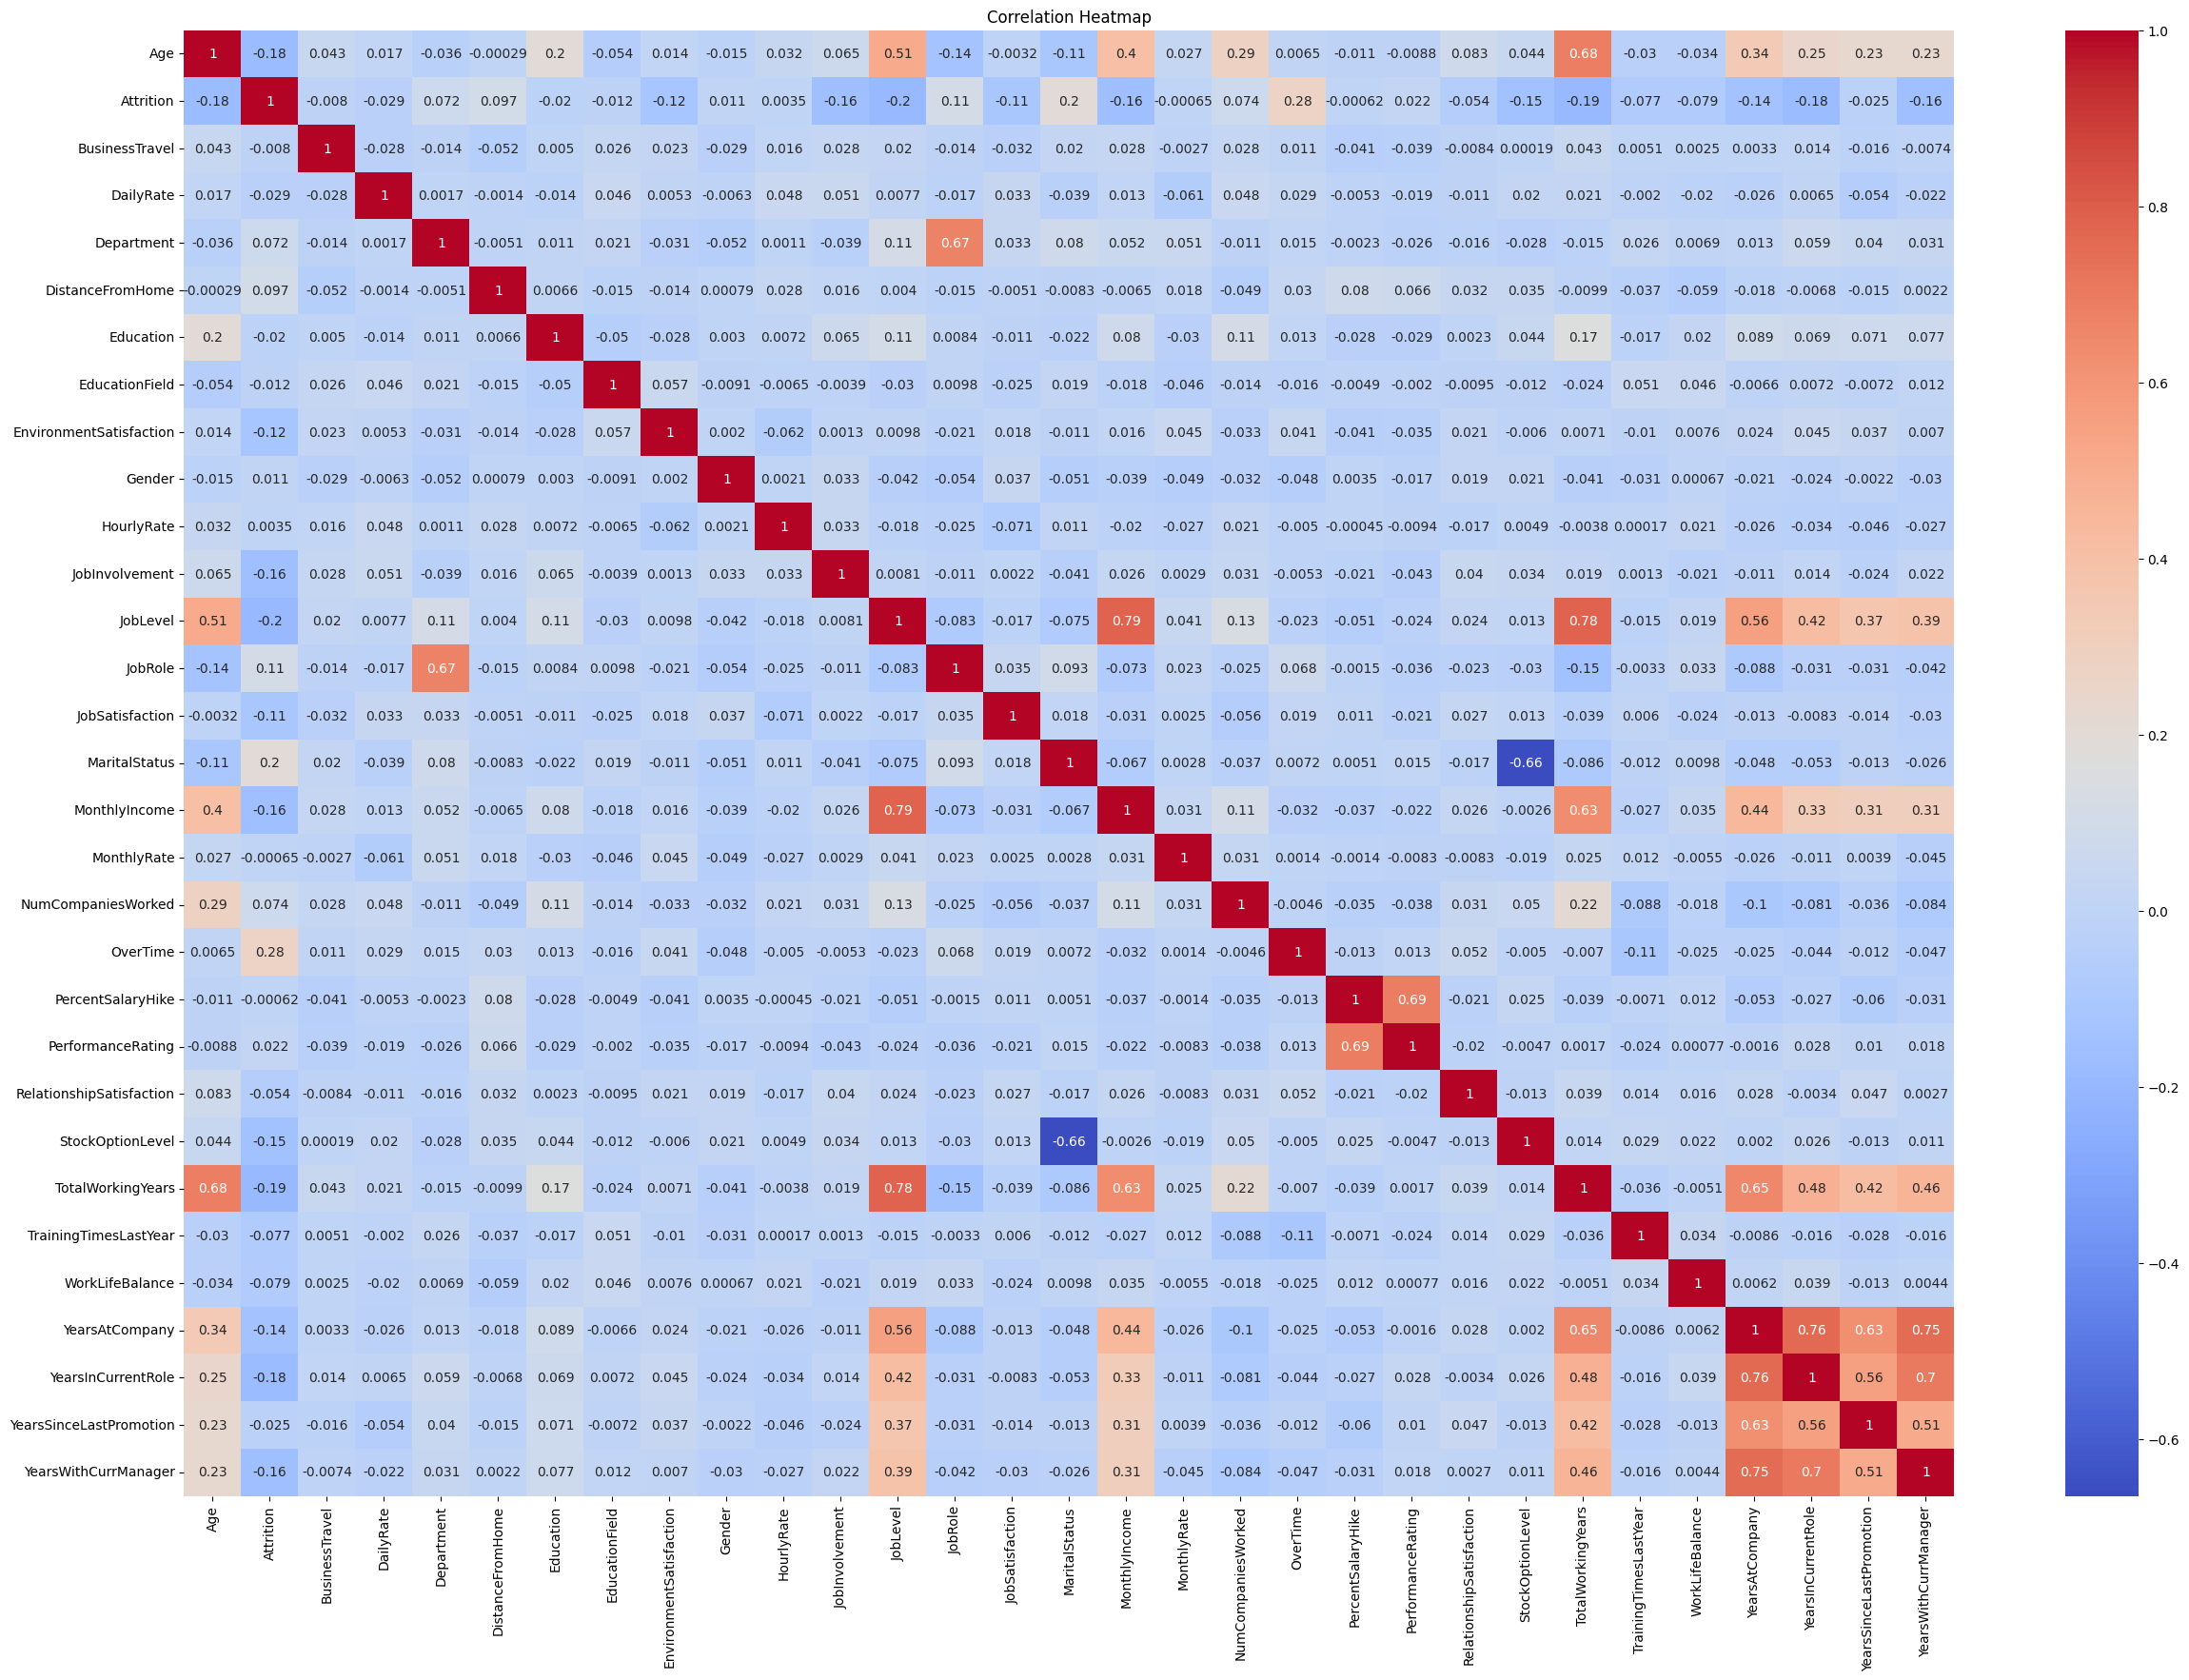

In [176]:
#HEATMAP
plt.figure(figsize=(30,20))
sns.heatmap(df.corr(),annot=True,cmap='coolwarm')
plt.title("Correlation Heatmap")
plt.show()

In [177]:
#FEATURE SELECTION,TRAIN TEST SPLIT & STANDARD SCALER
X = df.drop("Attrition", axis=1)
y = df["Attrition"]

print("X SHAPE :", X.shape)
print("Y SHAPE :", y.shape)

X_train, X_test, y_train, y_test = train_test_split(X,y,test_size=0.2,random_state=42)

scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

X SHAPE : (1652, 30)
Y SHAPE : (1652,)


In [178]:
#EVALUATION FUNCTION
results = []
def evaluate_model(name, y_test, y_pred):
    accuracy = accuracy_score(y_test, y_pred)
    precision = precision_score(y_test, y_pred)
    recall = recall_score(y_test, y_pred)
    f1 = f1_score(y_test, y_pred)
    roc = roc_auc_score(y_test, y_pred)
    
    results.append([name,accuracy,precision,recall,f1,roc])
    print(f"\n{name} RESULTS")
    print("Accuracy :", accuracy)
    print("Precision :", precision)
    print("Recall :", recall)
    print("F1 Score :", f1)
    print("ROC AUC :", roc)
    print("\nCLASSIFICATION REPORT")
    print(classification_report(y_test, y_pred))
    
    cm = confusion_matrix(y_test, y_pred)
    
    plt.figure(figsize=(6,4))
    sns.heatmap(cm,annot=True,fmt='d',cmap='coolwarm')
    plt.title(f"{name} Confusion Matrix")
    plt.xlabel("Predicted")
    plt.ylabel("Actual")
    plt.show()


Logistic Regression RESULTS
Accuracy : 0.8096676737160121
Precision : 0.7297297297297297
Recall : 0.5567010309278351
F1 Score : 0.631578947368421
ROC AUC : 0.7356154727288748

CLASSIFICATION REPORT
              precision    recall  f1-score   support

           0       0.83      0.91      0.87       234
           1       0.73      0.56      0.63        97

    accuracy                           0.81       331
   macro avg       0.78      0.74      0.75       331
weighted avg       0.80      0.81      0.80       331



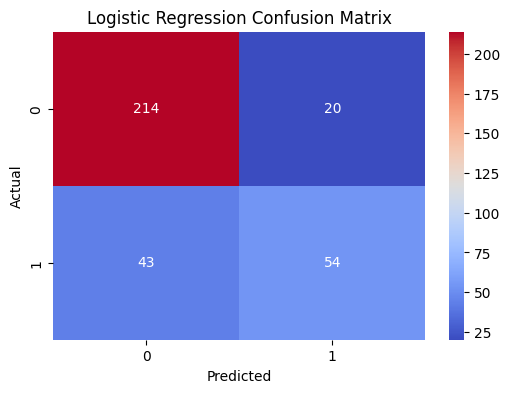

In [179]:
#LOGISTIC REGRESSION
lr = LogisticRegression(max_iter=1000)
lr.fit(X_train_scaled, y_train)
y_pred_lr = lr.predict(X_test_scaled)
evaluate_model("Logistic Regression",y_test,y_pred_lr)


Random Forest RESULTS
Accuracy : 0.9214501510574018
Precision : 0.9382716049382716
Recall : 0.7835051546391752
F1 Score : 0.8539325842696629
ROC AUC : 0.8810688166358268

CLASSIFICATION REPORT
              precision    recall  f1-score   support

           0       0.92      0.98      0.95       234
           1       0.94      0.78      0.85        97

    accuracy                           0.92       331
   macro avg       0.93      0.88      0.90       331
weighted avg       0.92      0.92      0.92       331



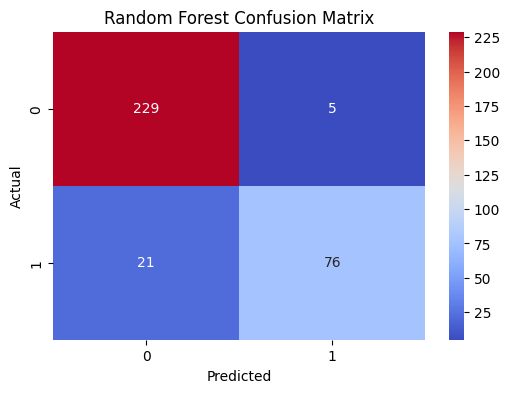

In [180]:
#RANDOM FOREST
rf = RandomForestClassifier(n_estimators=100,random_state=42)
rf.fit(X_train_scaled, y_train)
y_pred_rf = rf.predict(X_test_scaled)
evaluate_model("Random Forest",y_test,y_pred_rf)


CART Decision Tree RESULTS
Accuracy : 0.7945619335347432
Precision : 0.704225352112676
Recall : 0.5154639175257731
F1 Score : 0.5952380952380952
ROC AUC : 0.7128601638910917

CLASSIFICATION REPORT
              precision    recall  f1-score   support

           0       0.82      0.91      0.86       234
           1       0.70      0.52      0.60        97

    accuracy                           0.79       331
   macro avg       0.76      0.71      0.73       331
weighted avg       0.79      0.79      0.78       331



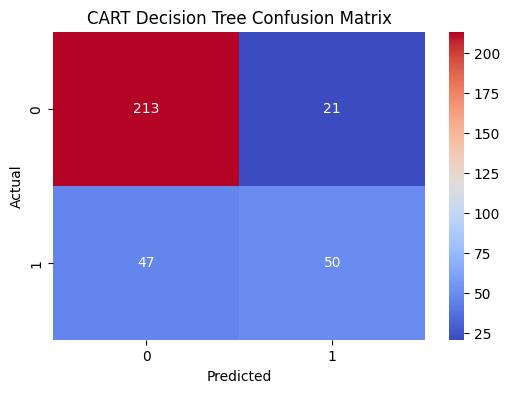

In [181]:
#CART DECISION TREE
dt = DecisionTreeClassifier(criterion='gini',max_depth=5,random_state=42)
dt.fit(X_train_scaled, y_train)
y_pred_dt = dt.predict(X_test_scaled)
evaluate_model("CART Decision Tree",y_test,y_pred_dt)


KNN RESULTS
Accuracy : 0.7764350453172205
Precision : 0.6825396825396826
Recall : 0.44329896907216493
F1 Score : 0.5375
ROC AUC : 0.6789144418010398

CLASSIFICATION REPORT
              precision    recall  f1-score   support

           0       0.80      0.91      0.85       234
           1       0.68      0.44      0.54        97

    accuracy                           0.78       331
   macro avg       0.74      0.68      0.70       331
weighted avg       0.76      0.78      0.76       331



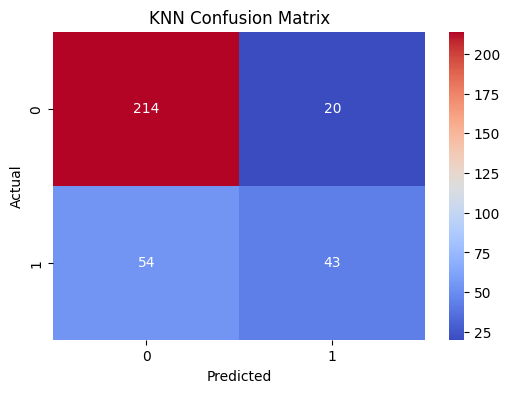

In [182]:
#KNN
knn = KNeighborsClassifier(n_neighbors=5)
knn.fit(X_train_scaled, y_train)
y_pred_knn = knn.predict(X_test_scaled)
evaluate_model("KNN",y_test,y_pred_knn)

C:\Users\hp\AppData\Roaming\Python\Python312\site-packages\xgboost\training.py:200: UserWarning: [00:12:44] WARNING: C:\actions-runner\_work\xgboost\xgboost\src\learner.cc:782: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)



XGBoost RESULTS
Accuracy : 0.9063444108761329
Precision : 0.84375
Recall : 0.8350515463917526
F1 Score : 0.8393782383419689
ROC AUC : 0.8854744911445943

CLASSIFICATION REPORT
              precision    recall  f1-score   support

           0       0.93      0.94      0.93       234
           1       0.84      0.84      0.84        97

    accuracy                           0.91       331
   macro avg       0.89      0.89      0.89       331
weighted avg       0.91      0.91      0.91       331



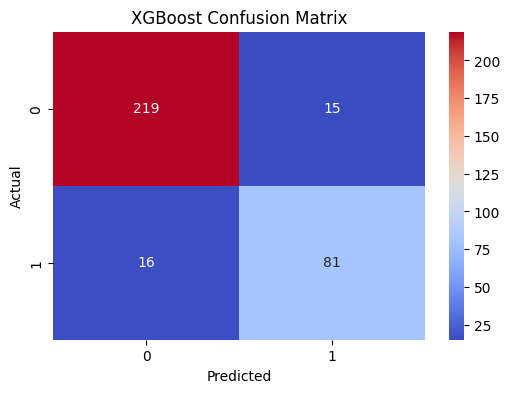

In [183]:
#XGBOOST
xgb_model = xgb.XGBClassifier(n_estimators=100, random_state=42, use_label_encoder=False, eval_metric='logloss')
xgb_model.fit(X_train_scaled, y_train)
y_pred_xgb = xgb_model.predict(X_test_scaled)
evaluate_model("XGBoost",y_test,y_pred_xgb)

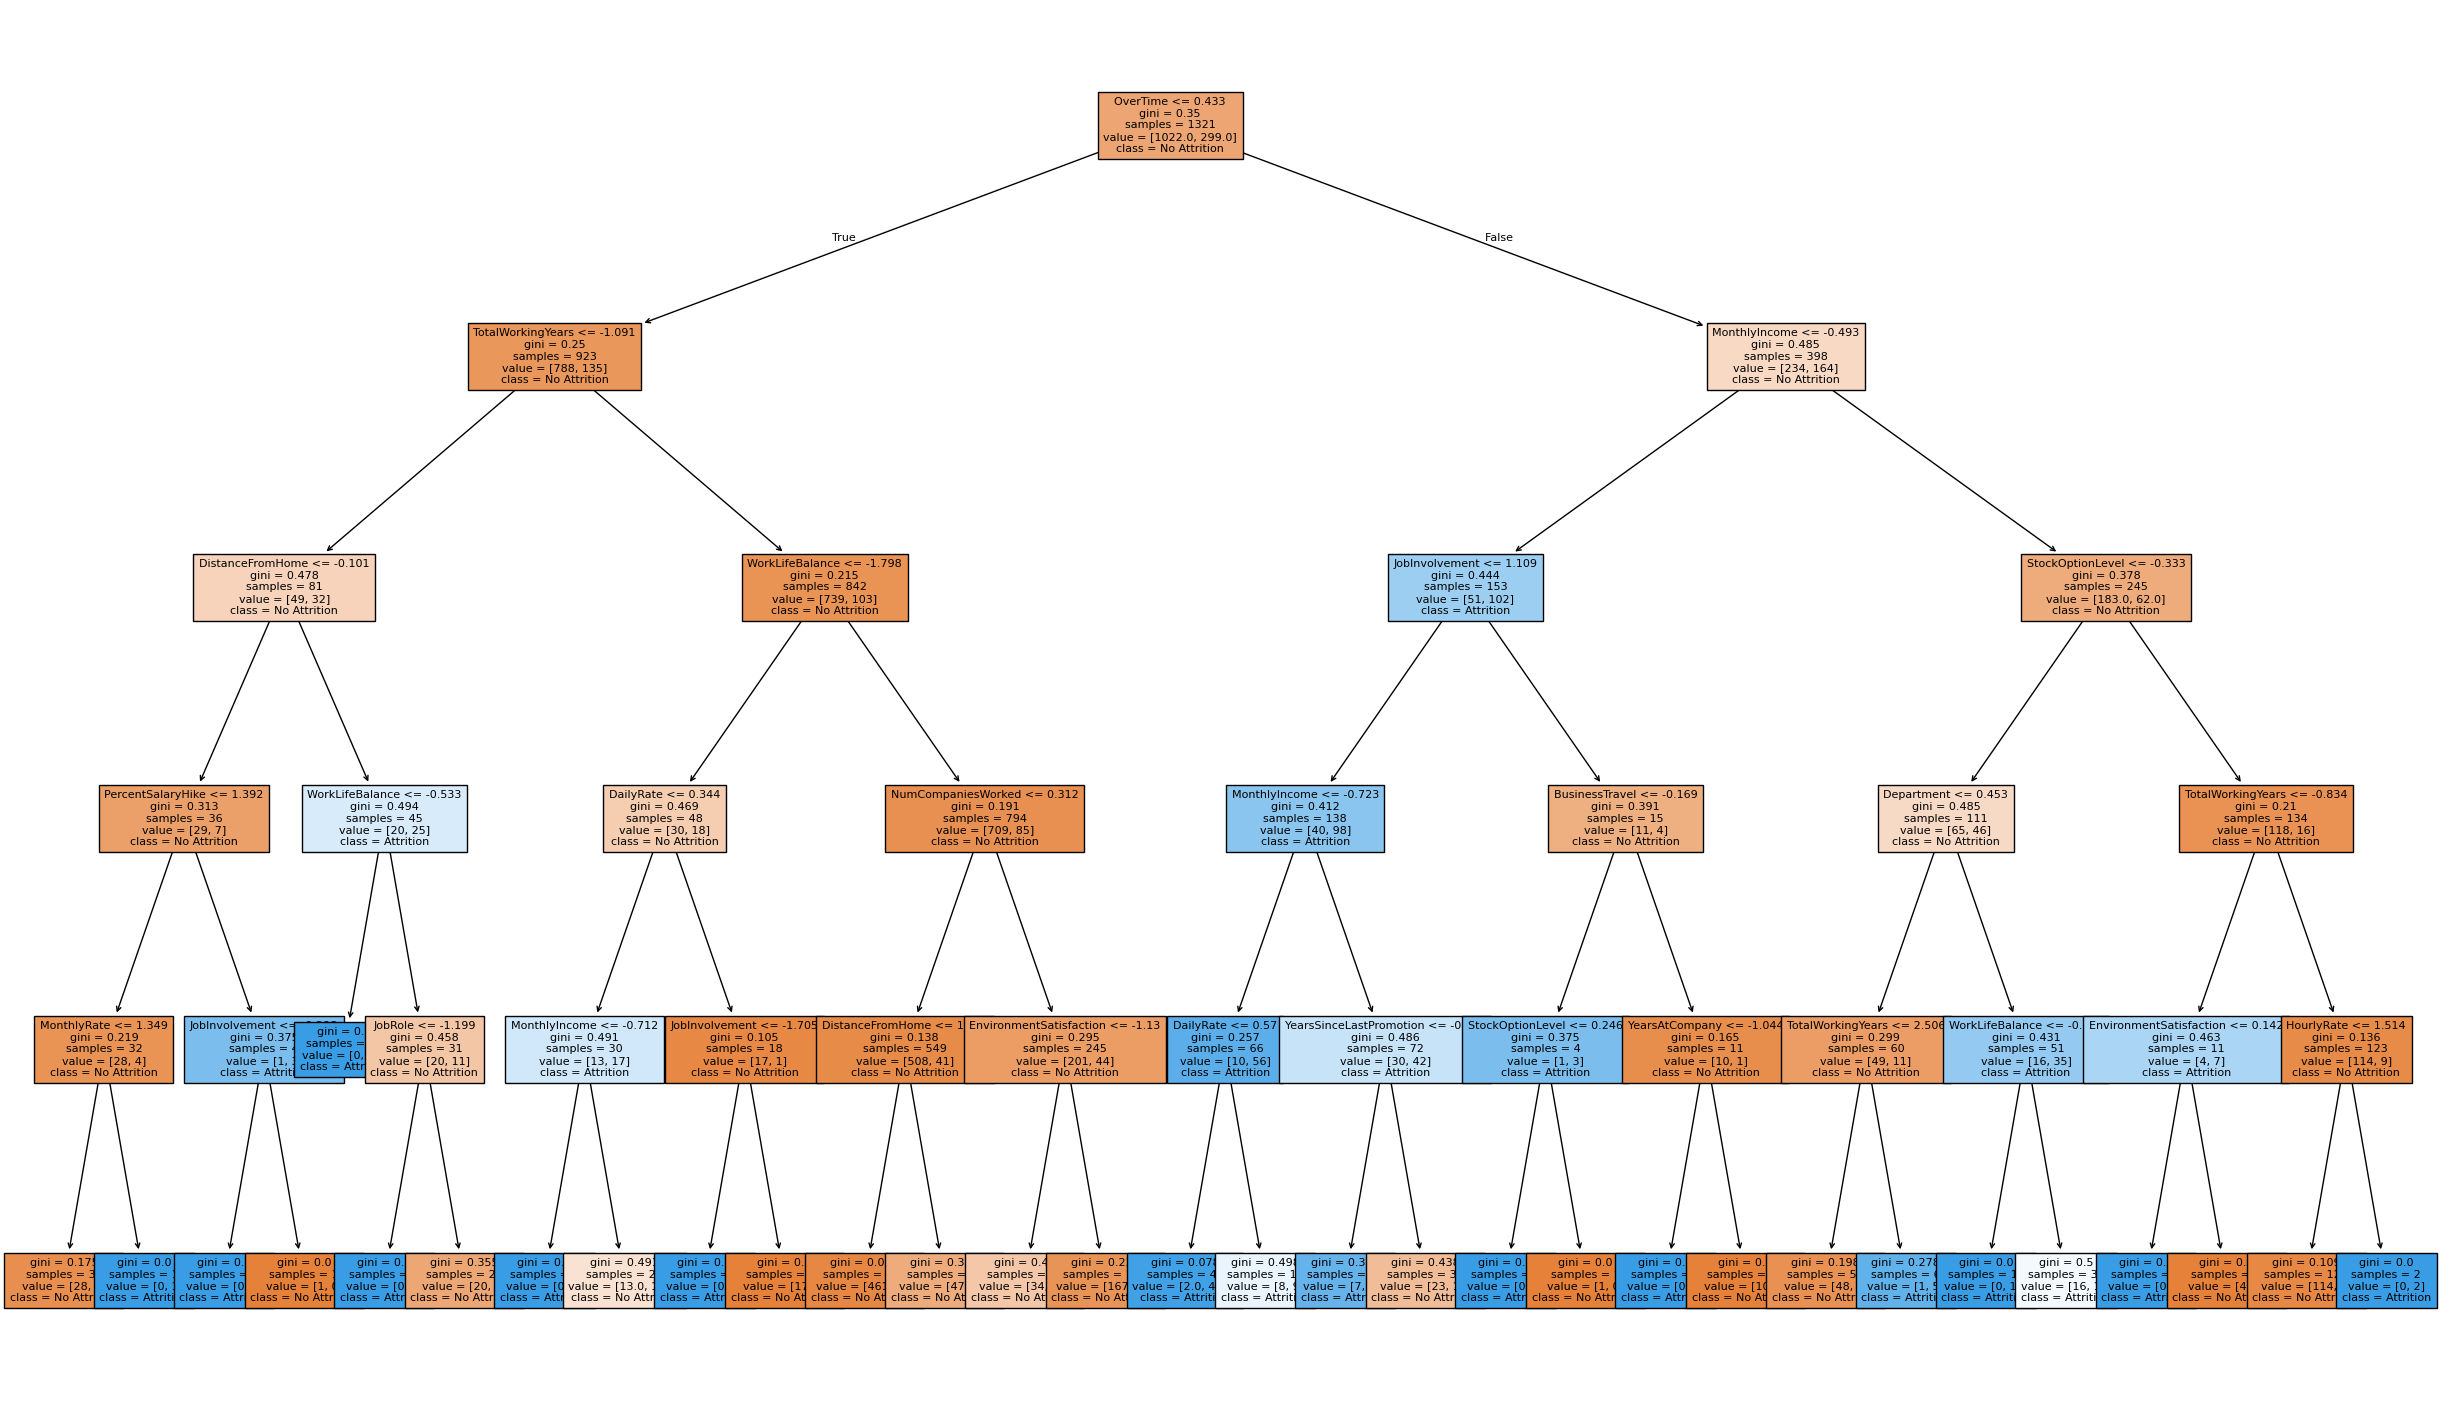

In [184]:
# DECISION TREE PLOT
plt.figure(figsize=(31,18))
plot_tree(dt,feature_names=X.columns,class_names=['No Attrition', 'Attrition'],filled=True,fontsize=8)
plt.show()

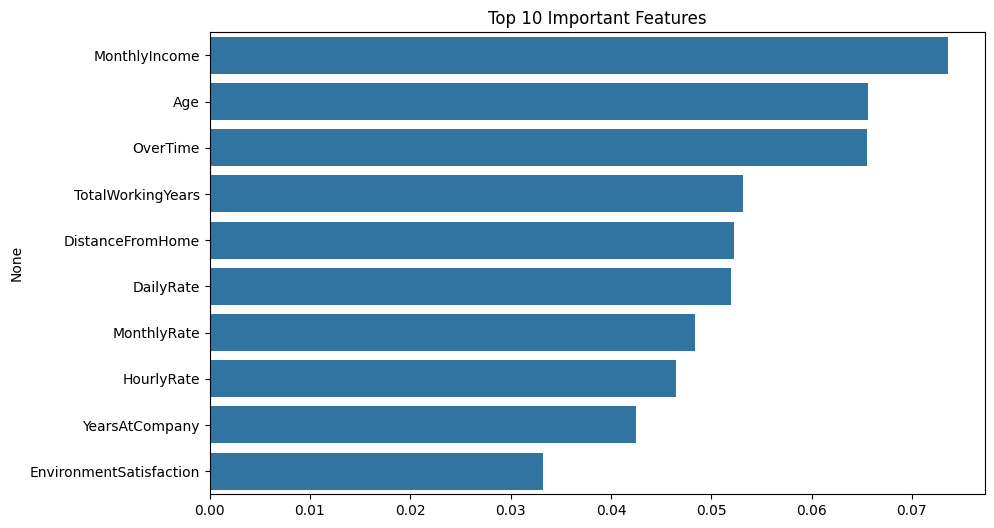

In [185]:
#RANDOM FOREST FEATURE IMPORTANCE
importance = pd.Series(rf.feature_importances_,index=X.columns)
importance = importance.sort_values(ascending=False)
plt.figure(figsize=(10,6))
sns.barplot(x=importance.values[:10],y=importance.index[:10])
plt.title("Top 10 Important Features")
plt.show()

,Model,Accuracy,Precision,Recall,F1 Score,ROC AUC
0,Logistic Regression,0.809668,0.729730,0.556701,0.631579,0.735615
1,Random Forest,0.921450,0.938272,0.783505,0.853933,0.881069
2,CART Decision Tree,0.794562,0.704225,0.515464,0.595238,0.712860
3,KNN,0.776435,0.682540,0.443299,0.537500,0.678914
4,XGBoost,0.906344,0.843750,0.835052,0.839378,0.885474


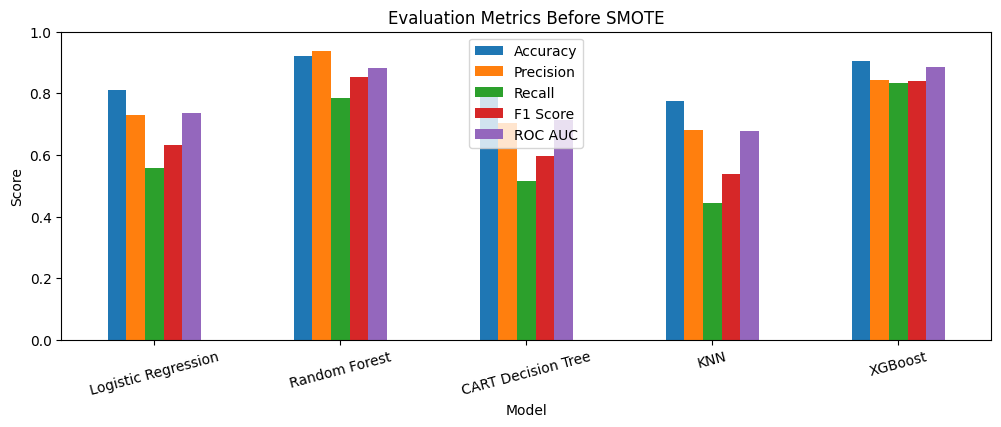

In [186]:
#COMPARISON TABLE
results_df = pd.DataFrame(results,columns=['Model','Accuracy','Precision','Recall','F1 Score','ROC AUC'])
display(results_df)

#METRICS GRAPH
metrics_df = results_df.set_index("Model")
metrics_df.plot(kind='bar',figsize=(12,4))
plt.title("Evaluation Metrics Before SMOTE")
plt.ylabel("Score")
plt.ylim(0,1)
plt.xticks(rotation=15)
plt.legend()
plt.show()

In [187]:
#APPLY SMOTE
smote = SMOTE(random_state=42)
X_smote, y_smote = smote.fit_resample(X_train_scaled,y_train)
print("Before SMOTE")
print(y_train.value_counts())
print("\nAfter SMOTE")
print(pd.Series(y_smote).value_counts())

Before SMOTE
Attrition
0    1022
1     299
Name: count, dtype: int64

After SMOTE
Attrition
0    1022
1    1022
Name: count, dtype: int64


In [188]:
#TRAIN MODELS AFTER SMOTE
smote_results = []
def evaluate_smote_model(name, y_test, y_pred):
    
    accuracy = accuracy_score(y_test, y_pred)
    precision = precision_score(y_test, y_pred)
    recall = recall_score(y_test, y_pred)
    f1 = f1_score(y_test, y_pred)
    roc = roc_auc_score(y_test, y_pred)
    smote_results.append([name,accuracy,precision,recall,f1,roc])
    
# Logistic Regression
lr_smote = LogisticRegression(max_iter=1000)
lr_smote.fit(X_smote, y_smote)
y_pred_lr_smote = lr_smote.predict(X_test_scaled)
evaluate_smote_model("LR + SMOTE",y_test,y_pred_lr_smote
                    )
# Random Forest
rf_smote = RandomForestClassifier(n_estimators=100,random_state=42)
rf_smote.fit(X_smote, y_smote)
y_pred_rf_smote = rf_smote.predict(X_test_scaled)
evaluate_smote_model("RF + SMOTE",y_test,y_pred_rf_smote)

# CART
dt_smote = DecisionTreeClassifier(criterion='gini',max_depth=5,random_state=42)
dt_smote.fit(X_smote, y_smote)
y_pred_dt_smote = dt_smote.predict(X_test_scaled)
evaluate_smote_model("DT + SMOTE",y_test,y_pred_dt_smote)

# KNN
knn_smote = KNeighborsClassifier(n_neighbors=5)
knn_smote.fit(X_smote, y_smote)
y_pred_knn_smote = knn_smote.predict(X_test_scaled)
evaluate_smote_model("KNN + SMOTE",y_test,y_pred_knn_smote)

# XGBoost
xgb_smote = xgb.XGBClassifier(n_estimators=100, random_state=42, use_label_encoder=False, eval_metric='logloss')
xgb_smote.fit(X_smote, y_smote)
y_pred_xgb_smote = xgb_smote.predict(X_test_scaled)
evaluate_smote_model("XGBoost + SMOTE",y_test,y_pred_xgb_smote)

C:\Users\hp\AppData\Roaming\Python\Python312\site-packages\xgboost\training.py:200: UserWarning: [00:12:46] WARNING: C:\actions-runner\_work\xgboost\xgboost\src\learner.cc:782: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


,Model,Accuracy,Precision,Recall,F1 Score,ROC AUC
0,LR + SMOTE,0.758308,0.562044,0.793814,0.658120,0.768702
1,RF + SMOTE,0.927492,0.929412,0.814433,0.868132,0.894396
2,DT + SMOTE,0.755287,0.564516,0.721649,0.633484,0.745440
3,KNN + SMOTE,0.737160,0.531646,0.865979,0.658824,0.774870
4,XGBoost + SMOTE,0.912387,0.854167,0.845361,0.849741,0.892766


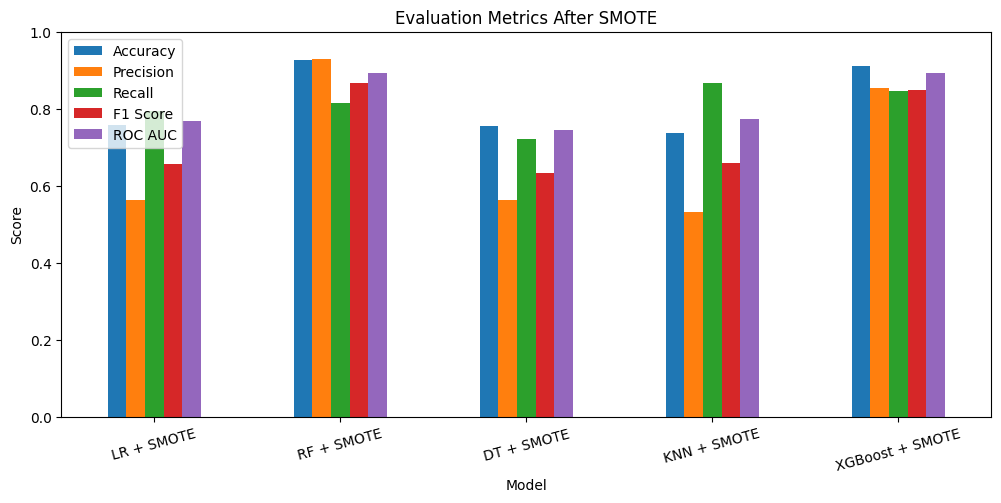

In [189]:
#SMOTE COMPARISON TABLE
smote_results_df = pd.DataFrame(smote_results,columns=['Model','Accuracy','Precision','Recall','F1 Score','ROC AUC'])
display(smote_results_df)

#AFTER SMOTE METRICS GRAPH
smote_metrics_df = smote_results_df.set_index("Model")
smote_metrics_df.plot(kind='bar',figsize=(12,5))
plt.title("Evaluation Metrics After SMOTE")
plt.ylabel("Score")
plt.ylim(0,1)
plt.xticks(rotation=15)
plt.legend()
plt.show()

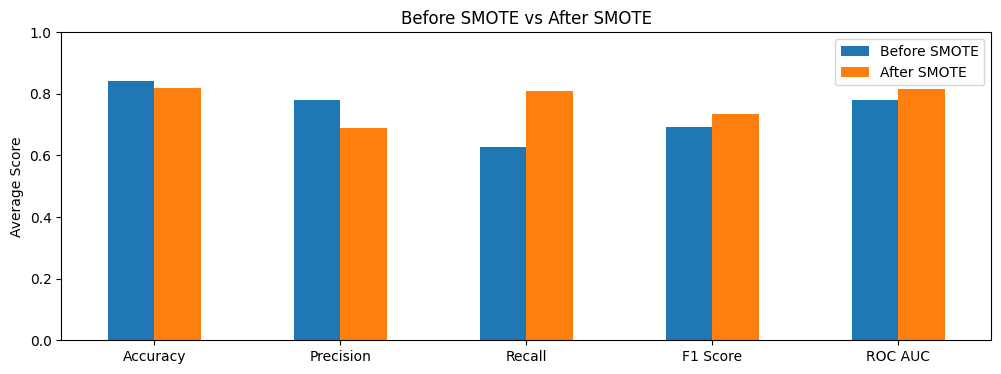

In [190]:
#BEFORE VS AFTER SMOTE COMPARISON
before_smote_avg = results_df.drop("Model", axis=1).mean()
after_smote_avg = smote_results_df.drop("Model", axis=1).mean()
comparison_df = pd.DataFrame({"Before SMOTE": before_smote_avg,"After SMOTE": after_smote_avg})
comparison_df.plot(kind='bar',figsize=(12,4))
plt.title("Before SMOTE vs After SMOTE")
plt.ylabel("Average Score")
plt.ylim(0,1)
plt.xticks(rotation=0)
plt.legend()
plt.show()